## Содержание:
* [Стационарность](#stacionary)
* [Преобразование Бокса-Кокса](#boxcox)
* [Модели для предсказания значений временного ряда](#predict)
* [Метрики точности прогноза](#metrics)

Импортируем библиотеки

In [3]:
# Импортируем необходимые библиотеки

import os
from os import path
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.tsa.api as smt

Рутина с датасетами

In [4]:
# загрузите данные о пассажирах
passengers = pd.read_csv(r'C:\01_Menu\01_Development\02_University_Labs\Third_Year\Time_Series\practice3\data\passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
passengers['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
df = passengers.set_index('Month').sort_index()

In [5]:
df.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


Отрисовываем временной ряд

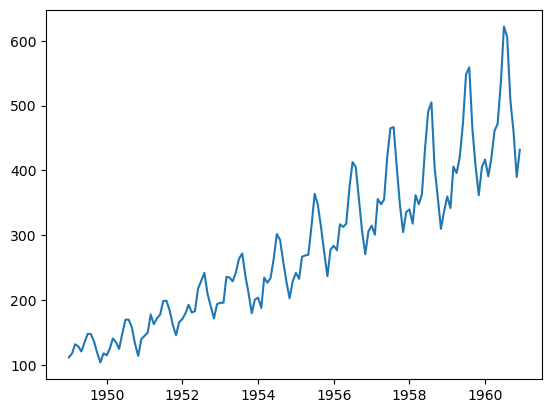

In [6]:
plt.plot(df["Passengers"])

## Стационарный процесс  <a class="anchor" id="stacionary"></a>

Стационарный процесс - это случайный процесс, безусловное совместное распределение вероятностей которого не изменяется при сдвиге во времени. Следовательно, такие параметры, как среднее значение и дисперсия, также не меняются со временем, поэтому стационарные временные ряды легче прогнозировать.

Есть несколько способов установить, является ли временной ряд стационарным или нет, наиболее распространенными являются старая добрая визуализация, просмотр автокорреляции и выполнение статистических тестов.

Наиболее распространенным тестом является тест Дики-Фуллера (также называемый тест ADF), где нулевая гипотеза состоит в том, что временной ряд имеет единичный корень, другими словами, временной ряд не является стационарным.

Мы проверим, можно ли отвергнуть нулевую гипотезу, сравнив значение p с выбранным порогом (α), чтобы, если значение p меньше, мы могли отклонить нулевую гипотезу и предположить, что временной ряд с уверенностью является стационарным. уровень 1-α (технически мы просто не можем сказать, что это не так)

Временной ряд имеет единичный корень, или порядок интеграции один, если его первые разности образуют стационарный ряд. Это условие записывается как
$y_t\thicksim I(1)$ если ряд первых разностей $\triangle y_t=y_t-y_{t-1}$ является стационарным $\triangle y_t\thicksim I(0)$.

При помощи этого теста проверяют значение коэффициента $a$ в  авторегрессионном уравнении первого порядка AR(1)
$y_t=a\cdot y_{t-1}+\varepsilon_t,$
где $y_t$ — временной ряд, а $\varepsilon$— ошибка.

Если $a=1$, то процесс имеет единичный корень, в этом случае ряд $y_t$ не стационарен, является интегрированным временным рядом первого порядка $I(1)$. Если $|a|<1$, то ряд стационарный $I(0)$.


In [7]:
# импортируем функцию, описывающую тест Дики-Фуллера
from statsmodels.tsa.stattools import adfuller

In [8]:
# всю теорию, описанную выше, реализуем с помощью statsmodels для проверки
# временного ряда перевозок на стационарность

alpha = 0.05
name = "Пассажиры"

# определяем временной ряд отдельной переменной
ts = df["Passengers"]

print(f'Тест Дики-Фуллера ряда {name} :')
# определяем результат значения теста из библиотеки с учетом
dftest = adfuller(ts, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

if dfoutput["p-value"] < alpha:
    print(f"Значение p меньше {alpha * 100}%. Ряд стационарный.")
else:
    print(f"Значение p больше {alpha*100}%. Ряд не стационарный.")

Тест Дики-Фуллера ряда Пассажиры :
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Значение p больше 5.0%. Ряд не стационарный.


А теперь попробуем осуществить дифференцирование. Перед этим опять попробуем декомпозицию ряда.

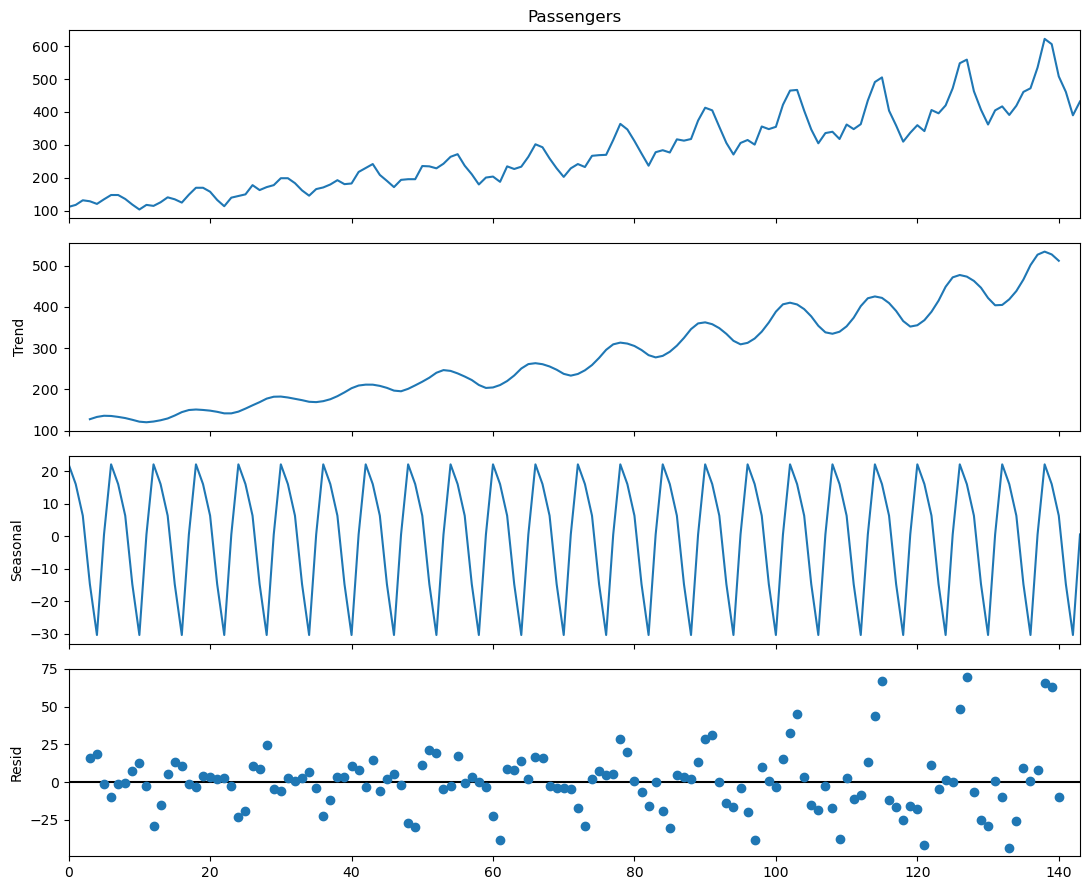

In [9]:
# импортируем функцию seasonal_decompose из statsmodels
# (то есть осуществляем декомпозицию сигнала/временного ряда)
from statsmodels.tsa.seasonal import seasonal_decompose

# задаем размер графика
from pylab import rcParams
rcParams['figure.figsize'] = 11, 9


# примените функцию seasonal_decompose к данным о перевозках
decompose = seasonal_decompose(passengers["Passengers"], 
                               period=6)
decompose.plot()
plt.show()

Создадим два временных ряда на основе имеющегося, только без тренда и сезонности.

Удаляем тренд согласно формуле: $y' = y_t - y_{t-1}$;

Удаляем сезонность согласно формуле: $y' = y_t - y_{t-s}$;

In [10]:
nottrend = []
s = 6
notseason = []

# выборка без тренда
for i in range(1, len(df["Passengers"])):
   nottrend.append(df["Passengers"][i] - df["Passengers"][i-1])

# выборка без сезонности
for i in range(s, len(df["Passengers"])):
   notseason.append(df["Passengers"][i] - df["Passengers"][i-s])


C:\Users\Syoshi\AppData\Local\Temp\ipykernel_34316\105335193.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nottrend.append(df["Passengers"][i] - df["Passengers"][i-1])
C:\Users\Syoshi\AppData\Local\Temp\ipykernel_34316\105335193.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  notseason.append(df["Passengers"][i] - df["Passengers"][i-s])


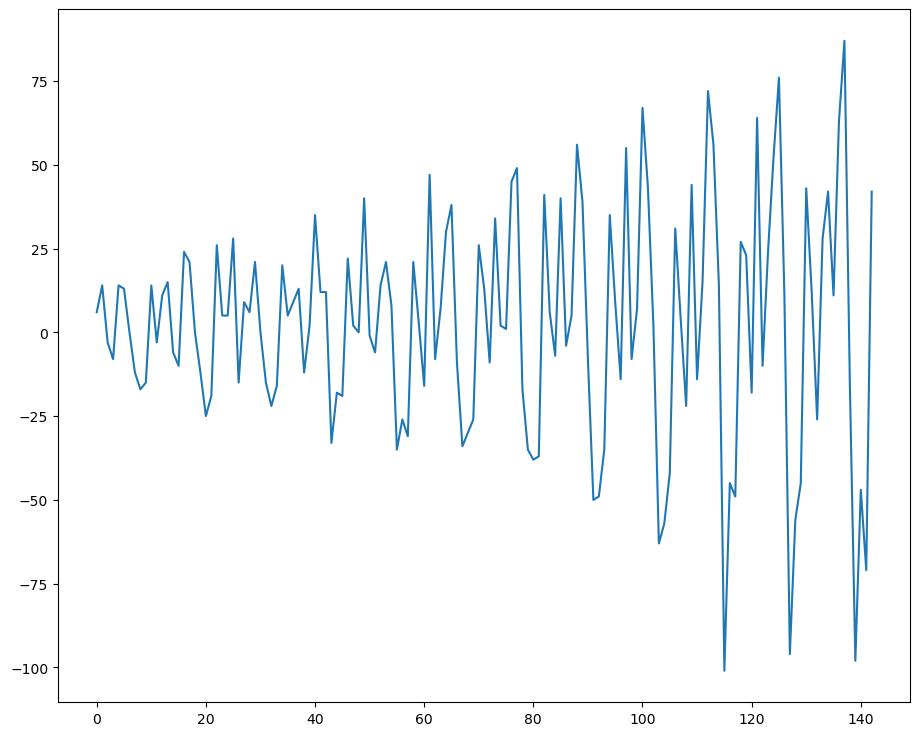

In [11]:
# отрисовываем временной ряд без тренда
plt.plot(nottrend)

Теперь проведем тест Дики-Фуллера на временном ряде без тренда

In [12]:
alpha = 0.05
name = "Пассажиры без тренда"
 
ts = nottrend

print(f'Тест Дики-Фуллера ряда {name} :')
dftest = adfuller(ts, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

if dfoutput["p-value"] < alpha:
    print(f"Значение p меньше {alpha * 100}%. Ряд стационарный.")
else:
    print(f"Значение p больше {alpha*100}%. Ряд не стационарный.")

Тест Дики-Фуллера ряда Пассажиры без тренда :
Test Statistic                  -2.829267
p-value                          0.054213
#Lags Used                      12.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Значение p больше 5.0%. Ряд не стационарный.


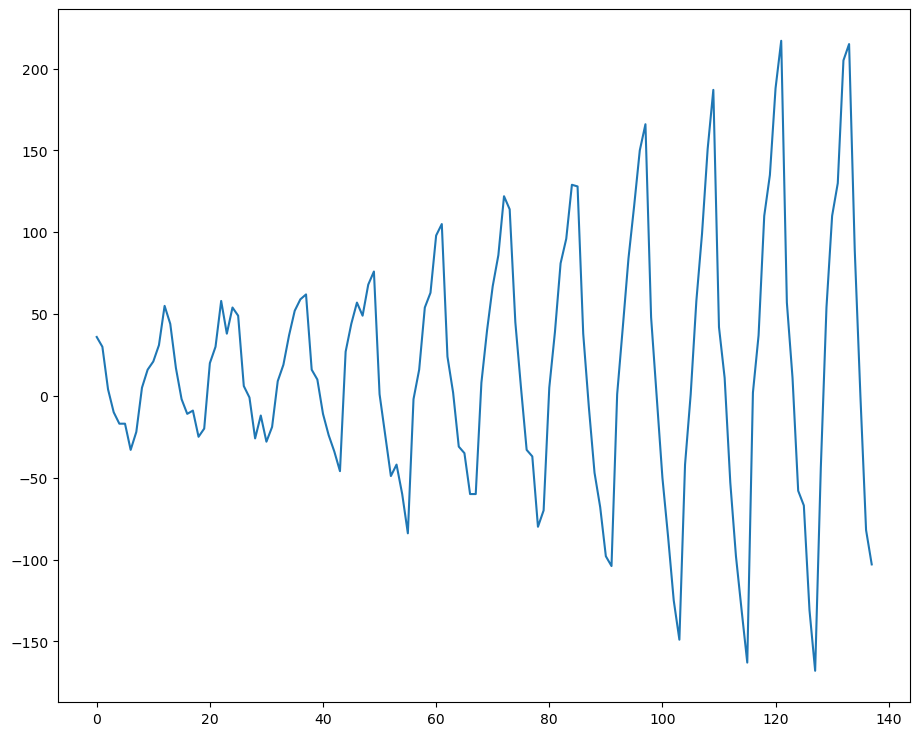

In [13]:
# отрисовываем временной ряд без сезонности
plt.plot(notseason)

Аналогичным образом проведем тест Дики-Фуллера на временном ряде без сезонности

In [14]:
alpha = 0.05
name = "Пассажиры без сезона"
 
ts = notseason

print(f'Тест Дики-Фуллера ряда {name} :')
dftest = adfuller(ts, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

if dfoutput["p-value"] < alpha:
    print(f"Значение p меньше {alpha * 100}%. Ряд стационарный.")
else:
    print(f"Значение p больше {alpha*100}%. Ряд не стационарный.")

Тест Дики-Фуллера ряда Пассажиры без сезона :
Test Statistic                  -3.154446
p-value                          0.022778
#Lags Used                       7.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64
Значение p меньше 5.0%. Ряд стационарный.


## Преобразование Бокса-Кокса <a class="anchor" id="boxcox"></a>

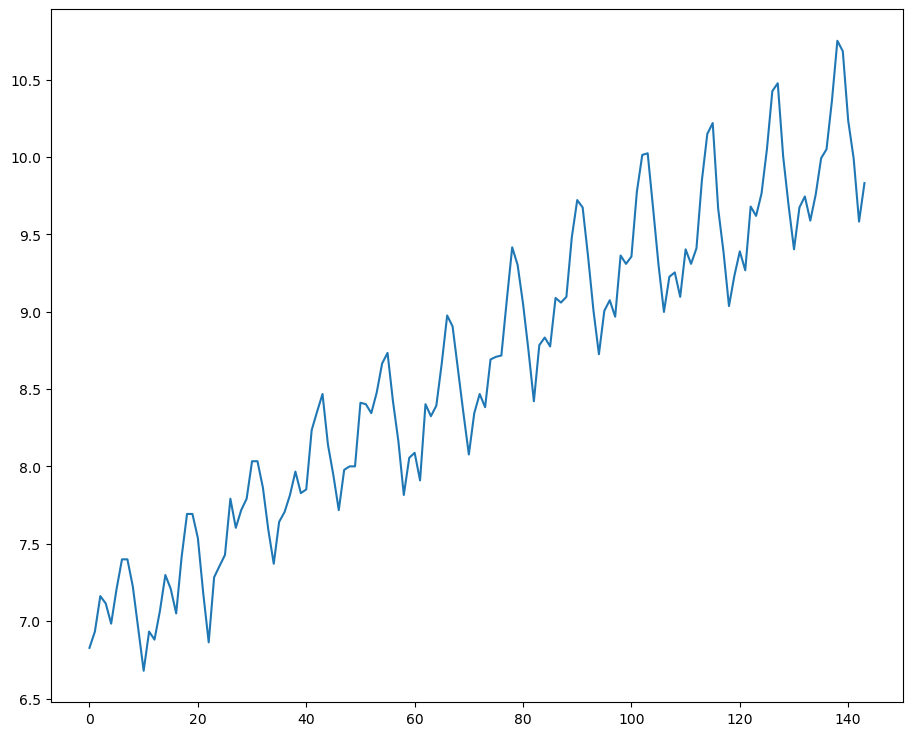

In [15]:
# Преобразование Бокса-Кокса
from scipy.stats import boxcox 

# вызываем функцию преобразования, которая выдает преобразованные данные и
# лучший параметр лямбда, который обеспечивает близость к нормальному
# распределению
transformed_data, best_lambda = boxcox(df["Passengers"]) 

# а теперь посмотрим на преобразованные данные
plt.plot(transformed_data) 

Попробуем теперь из преобразованного временного ряда удалить тренд и
визуализировать его

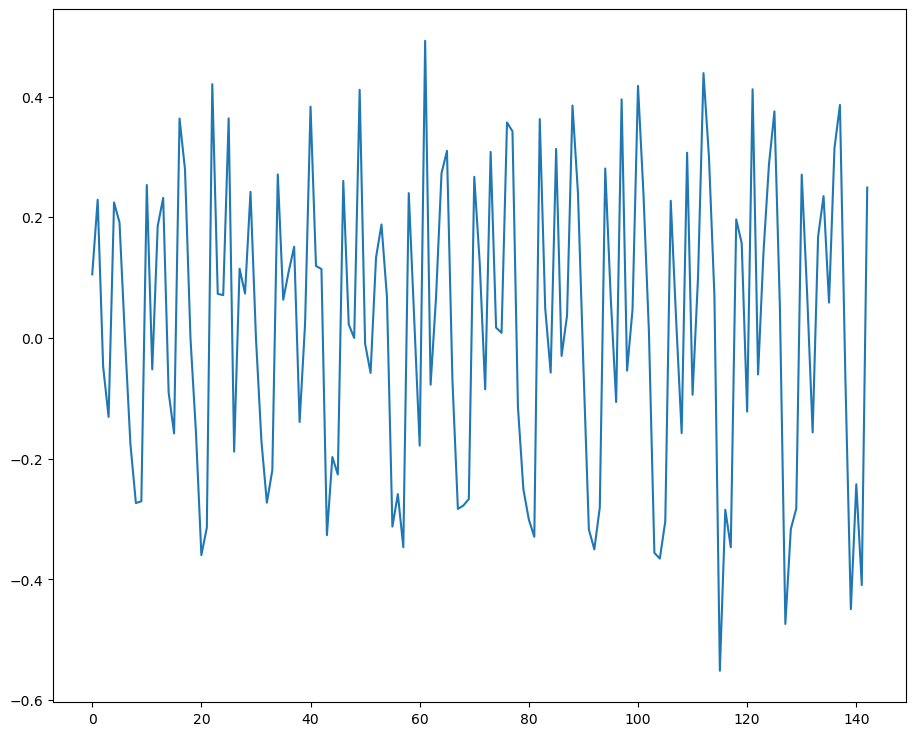

In [16]:
pnottrend = []

for i in range(1, len(transformed_data)):
   pnottrend.append(transformed_data[i] - transformed_data[i-1])


plt.plot(pnottrend) 

Удалив тренд из преобразованного Боксом-Коксом ряда, попробуем опять проверить его на стационарность. Что-то изменилось?

In [17]:
alpha = 0.05
name = "Пассажиры после Кокса-Бокса"
 
ts = pnottrend

print(f'Тест Дики-Фуллера ряда {name} :')
dftest = adfuller(ts, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

if dfoutput["p-value"] < alpha:
    print(f"Значение p меньше {alpha * 100}%. Ряд стационарный.")
else:
    print(f"Значение p больше {alpha*100}%. Ряд не стационарный.")

Тест Дики-Фуллера ряда Пассажиры после Кокса-Бокса :
Test Statistic                  -2.871707
p-value                          0.048738
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64
Значение p меньше 5.0%. Ряд стационарный.


Ответ:

Да, изменилось. Преобразование Бокса-Кокса сгладило растущую дисперсию (амплитуда колебаний перестала расширяться с течением времени), а дифференцирование убило тренд. В итоге тест Дики-Фуллера для такого ряда должен показать p-value сильно ниже a(0.05), что доказывает его стационарность.

## Модели для предсказания значений временного ряда <a class="anchor" id="predict"></a>

Первой моделью будет модель **AR**, или же autoregression - модель, которая использует связь между наблюдением и некоторым количеством предыдущих наблюдений.​

Сделаем случайный ряд и затем поработаем с ним.

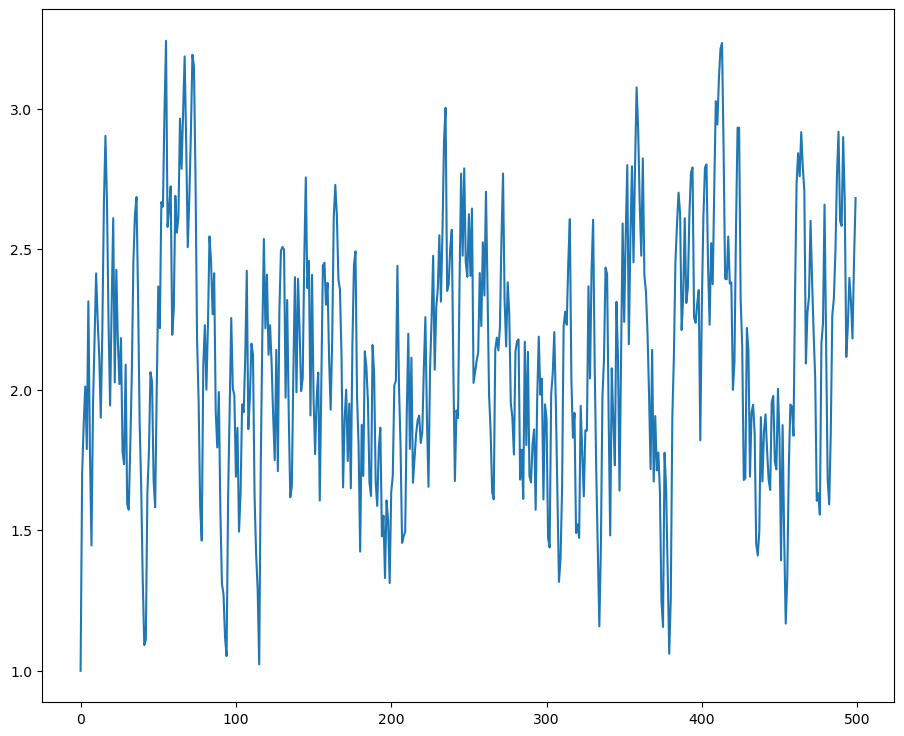

In [18]:
# AR(1)

N = 500

ar1 = [1]

for i in range(1, N):
    ar1.append(0.76 * ar1[i-1] + np.random.random())

plt.plot(ar1)

Посмотрим какие у него стандартное отклонение и среднее.

In [19]:
print(f"standart deviation = {np.std(ar1)}\n mean = {np.mean(ar1)}")

standart deviation = 0.44093319303215117
 mean = 2.110667592314038


А теперь обернем его в датафрейм и посмотрим его обычную и частичную автокорреляцию. Что можно сказать по поводу этого временного ряда, глядя на эти параметры?

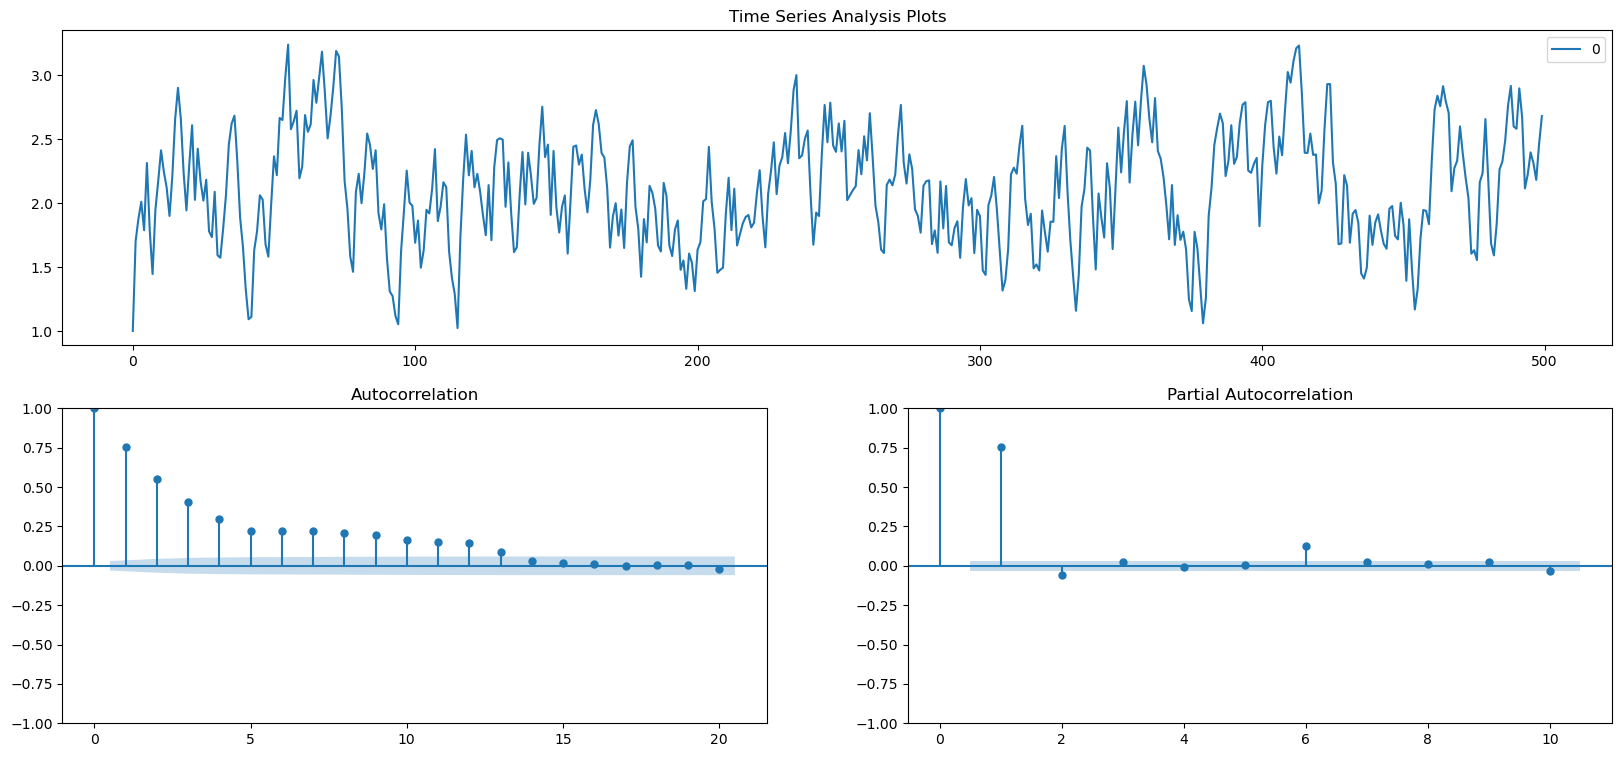

In [20]:
ts = pd.DataFrame(ar1)

fig = plt.figure(figsize=(20, 9))
layout = (2, 2)
ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
acf_ax = plt.subplot2grid(layout, (1, 0))
pacf_ax = plt.subplot2grid(layout, (1, 1))

ts.plot(ax=ts_ax)
ts_ax.set_title('Time Series Analysis Plots')
smt.graphics.plot_acf(ts, lags=20, ax=acf_ax, alpha=0.5)
smt.graphics.plot_pacf(ts, lags=10, ax=pacf_ax, alpha=0.5)
None

Ответ: 

График PACF (частичной автокорреляции) резко обрывается после первого лага — это главный индикатор того, что перед нами процесс авторегрессии именно первого порядка AR(1). ACF (обычная автокорреляция) при этом затухает плавно, экспоненциально. Поскольку коэффициент 0.76 < 1, ряд стационарен.

Сделаем ещё один случайный ряд, но уже и с отрицательными значениями коэффициента

standart deviation = 0.4351036966821072
 mean = 0.28646719284674976


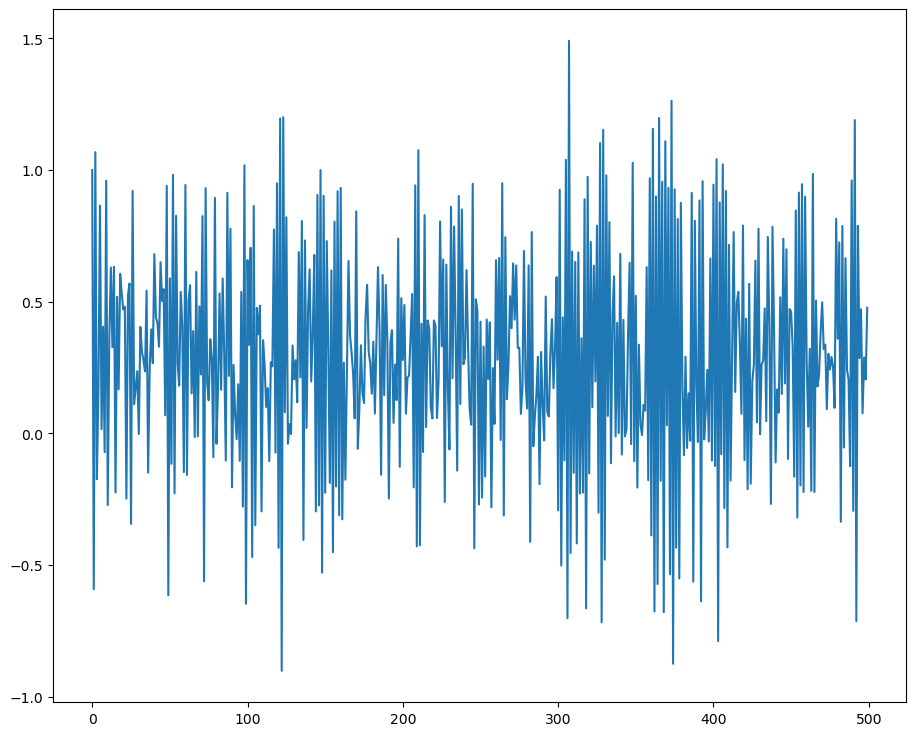

In [21]:
# AR(1)

N = 500

ar2 = [1]

for i in range(1, N):
    ar2.append(- 0.76*ar2[i-1] + np.random.random())

plt.plot(ar2)

print(f"standart deviation = {np.std(ar2)}\n mean = {np.mean(ar2)}")

А что можно сказать по поводу этого ряда?

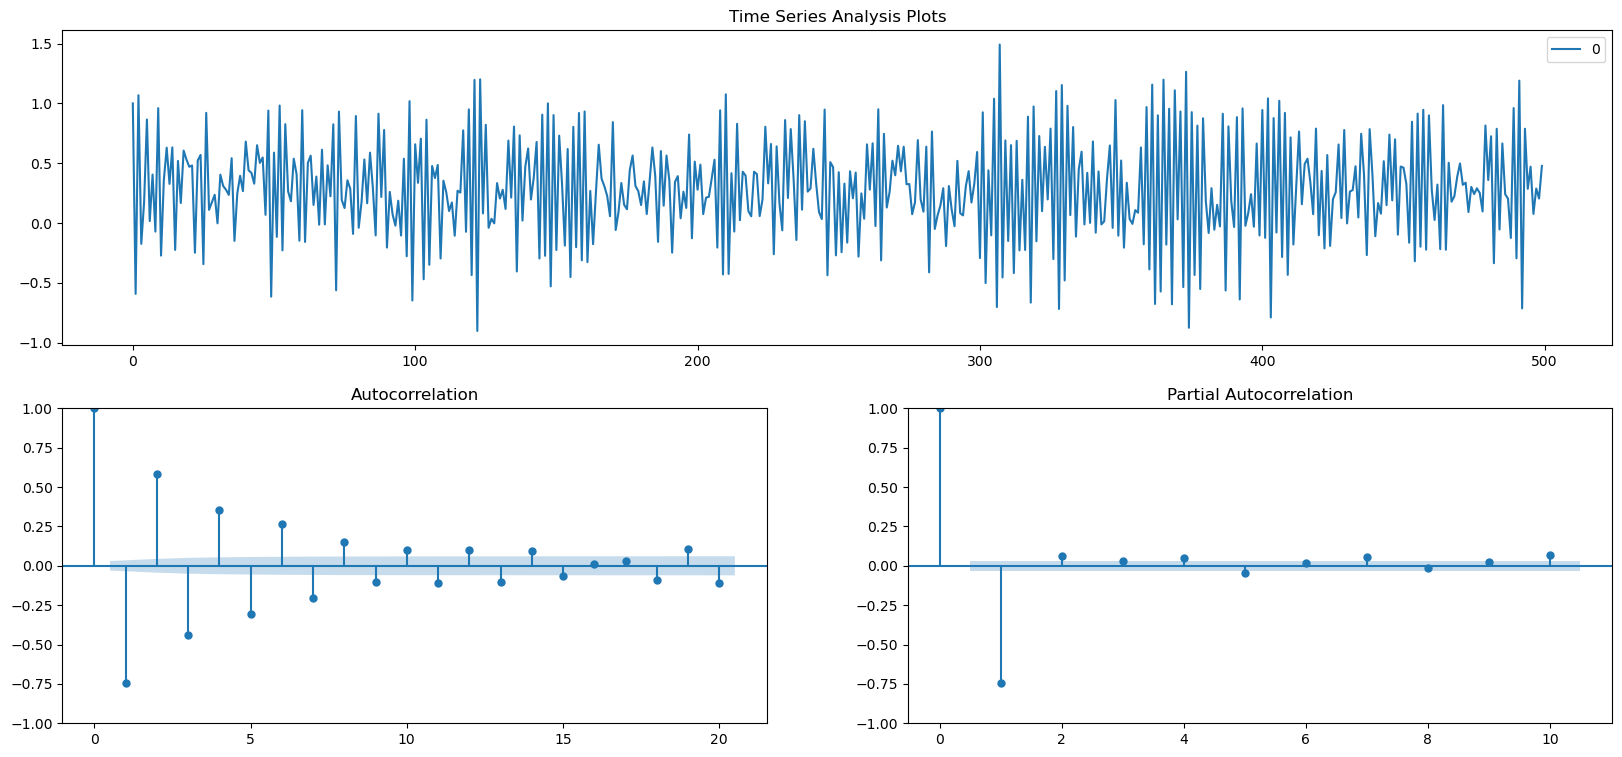

In [22]:
ts = pd.DataFrame(ar2)

fig = plt.figure(figsize=(20, 9))
layout = (2, 2)
ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
acf_ax = plt.subplot2grid(layout, (1, 0))
pacf_ax = plt.subplot2grid(layout, (1, 1))

ts.plot(ax=ts_ax)
ts_ax.set_title('Time Series Analysis Plots')
smt.graphics.plot_acf(ts, lags=20, ax=acf_ax, alpha=0.5)
smt.graphics.plot_pacf(ts, lags=10, ax=pacf_ax, alpha=0.5)
None

Ответ:

Здесь PACF тоже обрывается после первого лага, но пик направлен вниз (в отрицательную зону). Из-за отрицательного коэффициента график ACF будет осциллирующим (знаки корреляции чередуются: плюс, минус, плюс, минус), затухая по амплитуде. Ряд всё ещё стационарен, так как по модулю |-0.76| < 1

А теперь коэффициент >1 

standart deviation = 0.4351036966821072
 mean = 0.28646719284674976


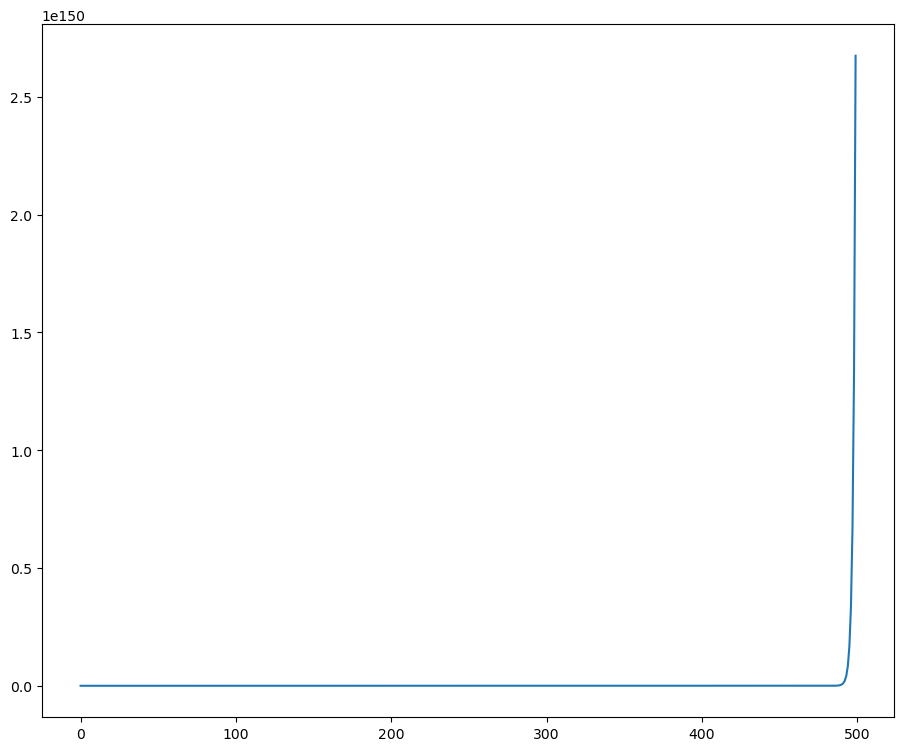

In [23]:
# AR(1)

N = 500

ar3 = [1]

for i in range(1, N):
    ar3.append(2 * ar3[i-1] + np.random.random())

plt.plot(ar3)

print(f"standart deviation = {np.std(ar2)}\n mean = {np.mean(ar2)}")

Ладно, пора возвращаться к прогнозированию. Следаем прогноз с помощью AR модели, предварительно поделив выборки на обучающую, валидационную и тестовую.

In [24]:
df = pd.read_csv('data/passengers.csv', names=["n","x"], skiprows=1)


df['t'] = df.index.values

ln = len(df)

# указываем 'объемы' выборок
train_cutoff = int(round(ln*0.75, 0))
validate_cutoff = int(round(ln*0.90,0))

# делим выборки
train_df = df[df['t'] <= train_cutoff]
validate_df = df[(df['t'] > train_cutoff) & (df['t'] <= validate_cutoff)]
forecast_df = df[df['t'] > validate_cutoff]

Визуализируем поделенные выборки.

* Обучающая выборка - синим цветом
* Валидационная выборка - оранжевым цветом
* Предсказываемая выборка - зеленым цветом

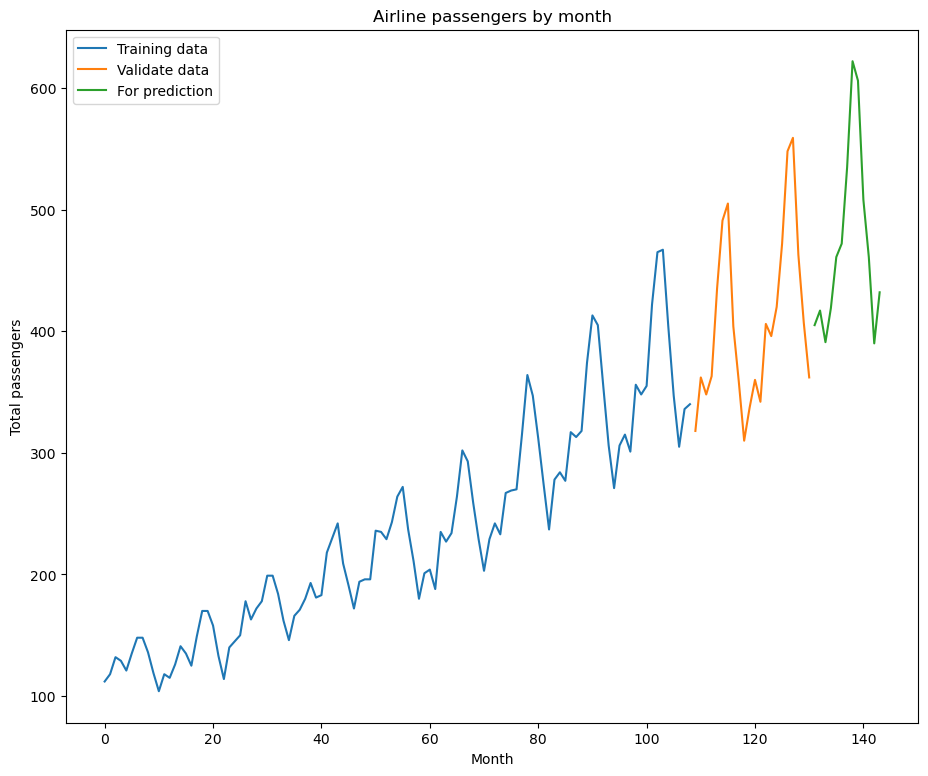

In [25]:
plt.plot(train_df.t, train_df.x, label='Training data')
plt.plot(validate_df.t, validate_df.x, label='Validate data')
plt.plot(forecast_df.t, forecast_df.x, label='For prediction')
plt.legend()
plt.title('Airline passengers by month')
plt.ylabel('Total passengers')
plt.xlabel('Month')
plt.show()

In [26]:
from statsmodels.tsa.ar_model import AutoReg, ar_select_order

In [27]:
# создаем объект модели на основе данных временного ряда с 3 лагами
mod = AutoReg(df.t, 3, old_names=False)
# обучаем
res = mod.fit()

# выводим сводку информации об авторегрессионной модели
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:                      t   No. Observations:                  144
Model:                     AutoReg(3)   Log Likelihood                4046.071
Method:               Conditional MLE   S.D. of innovations              0.000
Date:                Sun, 31 May 2026   AIC                          -8082.142
Time:                        00:15:41   BIC                          -8067.398
Sample:                             3   HQIC                         -8076.150
                                  144                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6667   4.68e-15   1.43e+14      0.000       0.667       0.667
t.L1           1.0000   4.63e-15   2.16e+14      0.000       1.000       1.000
t.L2           0.3333   5.71e-17   5.83e+15      0.0

In [28]:
# опять обучаем модель, но на этот раз указываем тип ковариационной оценки
res = mod.fit(cov_type="HC0")

# смотрим, что изменилось
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:                      t   No. Observations:                  144
Model:                     AutoReg(3)   Log Likelihood                4046.071
Method:               Conditional MLE   S.D. of innovations              0.000
Date:                Sun, 31 May 2026   AIC                          -8082.142
Time:                        00:15:41   BIC                          -8067.398
Sample:                             3   HQIC                         -8076.150
                                  144                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6667   4.26e-15   1.56e+14      0.000       0.667       0.667
t.L1           1.0000   4.21e-15   2.37e+14      0.000       1.000       1.000
t.L2           0.3333   5.82e-17   5.72e+15      0.0

Продолжаем экспериментировать

In [29]:
sel = ar_select_order(df.x, 13, old_names=False)
sel.ar_lags
res = sel.model.fit()
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:                      x   No. Observations:                  144
Model:                    AutoReg(13)   Log Likelihood                -497.994
Method:               Conditional MLE   S.D. of innovations             10.832
Date:                Sun, 31 May 2026   AIC                           1025.988
Time:                        00:15:41   BIC                           1069.116
Sample:                            13   HQIC                          1043.513
                                  144                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1490      2.857      1.802      0.072      -0.451      10.749
x.L1           0.7608      0.070     10.885      0.000       0.624       0.898
x.L2          -0.0853      0.069     -1.229      0.2

Смотрим, что он предсказал

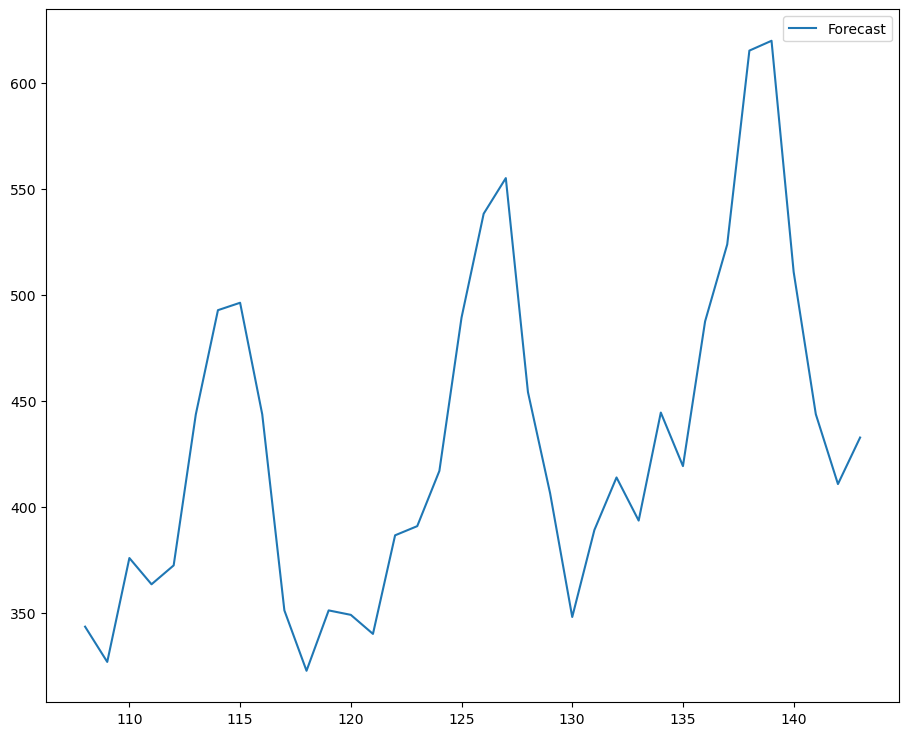

In [30]:
fig = res.plot_predict(train_cutoff)

Формируем предсказанные временные ряды

In [31]:
pred = res.predict(start=0, end=train_cutoff, dynamic=False)
v_pred = res.predict(start=train_cutoff+1, end=(validate_cutoff), dynamic=False)
f_pred = res.predict(start=validate_cutoff + 1, end=(forecast_df.t[len(df.t)-1]), dynamic=False)

Отрисовываем их

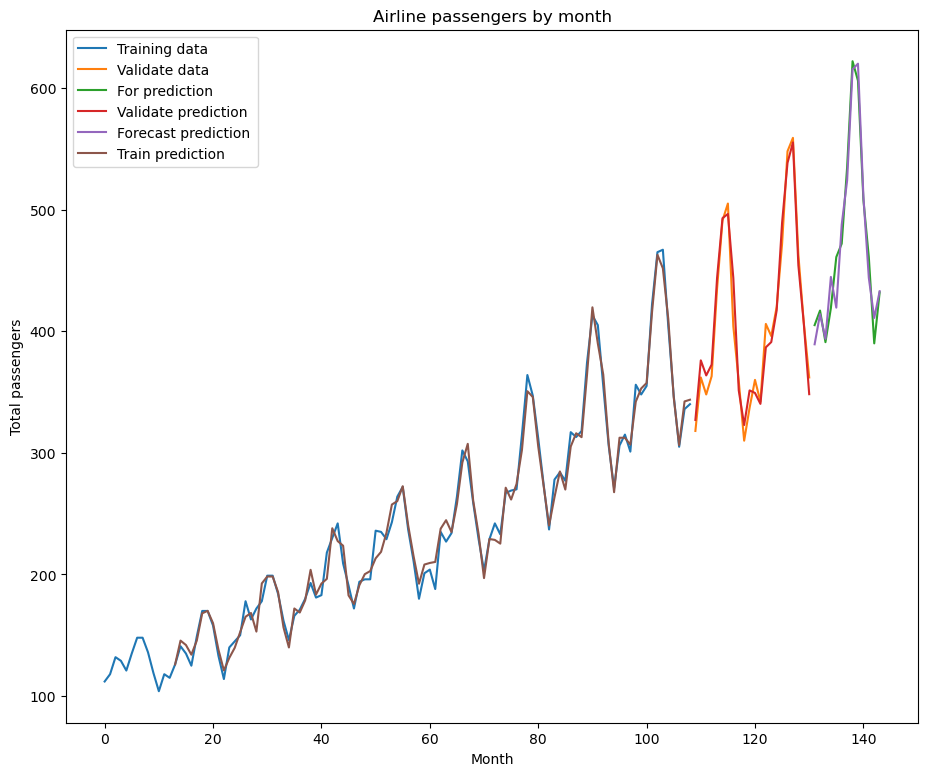

In [32]:
plt.plot(train_df.t, train_df.x, label='Training data')
plt.plot(validate_df.t, validate_df.x, label='Validate data')
plt.plot(forecast_df.t, forecast_df.x, label='For prediction')
plt.plot(validate_df.t, v_pred, label='Validate prediction ')
plt.plot(forecast_df.t, f_pred, label='Forecast prediction')
plt.plot(train_df.t, pred, label='Train prediction')

plt.legend()
plt.title('Airline passengers by month')
plt.ylabel('Total passengers')
plt.xlabel('Month')
plt.show()

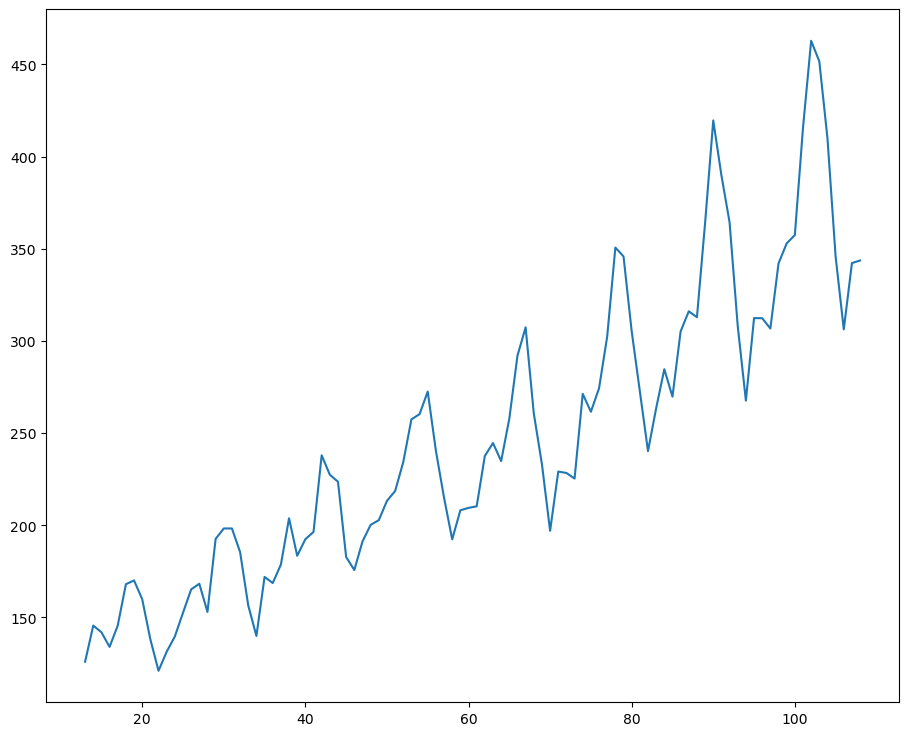

In [33]:
plt.plot(pred)

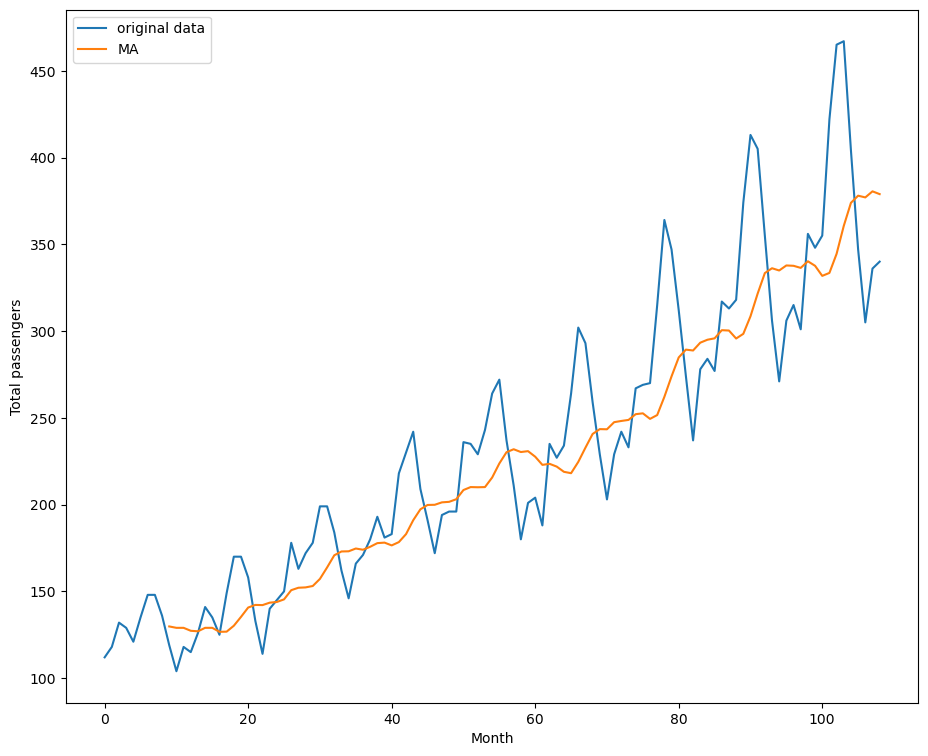

In [34]:
# MA

df['t'] = df.index.values

ln = len(df)

# указываем 'объемы' выборок
train_cutoff = int(round(ln*0.75, 0))
validate_cutoff = int(round(ln*0.90,0))

# делим выборки
train_df = df[df['t'] <= train_cutoff]
validate_df = df[(df['t'] > train_cutoff) & (df['t'] <= validate_cutoff)]
forecast_df = df[df['t'] > validate_cutoff]

plt.plot(train_df["t"], train_df["x"], label="original data")
plt.plot(train_df["t"], train_df["x"].rolling(10).mean(), label="MA")
plt.legend()
plt.ylabel('Total passengers')
plt.xlabel('Month')
plt.show()

## Метрики точности прогноза <a class="anchor" id="metrics"></a>

* R2- коэффициент детерминации     ​
* MSE (RMSE) – mean squared error – среднеквадратичная ошибка​
* MAE – mean absolute error – средняя абсолютная ошибка​
* MAPE – mean absolute percentage error – средняя абсолютная ошибка в %​
* SMAPE – symmetric mean absolute percentage error – симметричная средняя абсолютная ошибка в %

Определяем метрики точности прогноза из библиотеки sklearn. Попробуй определить последнюю оставшуюся метрику **SMAPE** самостоятельно.

In [35]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score

In [36]:
def smape(y_true, y_pred):
    return 100 / len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

Вычислим значения ошибок модели AR, опираясь на предсказанные ею значения forecast.

In [37]:
print("RMSE:", np.sqrt(mean_squared_error(forecast_df.x, f_pred)))
print("MAPE:", mean_absolute_percentage_error(forecast_df.x, f_pred))
print("MAE:", mean_absolute_error(forecast_df.x, f_pred))
print("R2: ", r2_score(forecast_df.x, f_pred))

RMSE: 17.540788248085807
MAPE: 0.030039826361233143
MAE: 13.680314913378888
R2:  0.943782157808506


# **Задание:** Изучить, как работает модель авторегрессии (AR) на временном ряду и оценить её качество.

In [38]:
# Простыми словами, нужно сделать задание по аналогии с тем нестационарным временным рядом (см. выше). 

In [39]:


from statsmodels.tsa.arima_process import arma_generate_sample

np.random.seed(42)

# AR(2) процесс
ar_data = arma_generate_sample(
    ar=np.array([1.0, -0.5, 0.7]),
    ma=np.array([1]),
    nsample=200,
    scale=1,
    burnin=1000
)

time = np.arange(200)

trend = time * 0.2
seasonality = 2 * np.sin(2 * np.pi * time / 12)

time_series = trend + seasonality + ar_data

df = pd.DataFrame({
    "t": time,
    "x": time_series
})

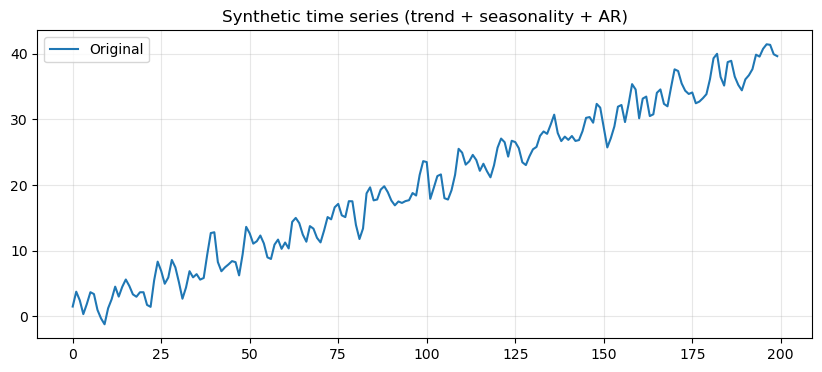

In [40]:
plt.figure(figsize=(10,4))
plt.plot(df.t, df.x, label="Original")
plt.title("Synthetic time series (trend + seasonality + AR)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

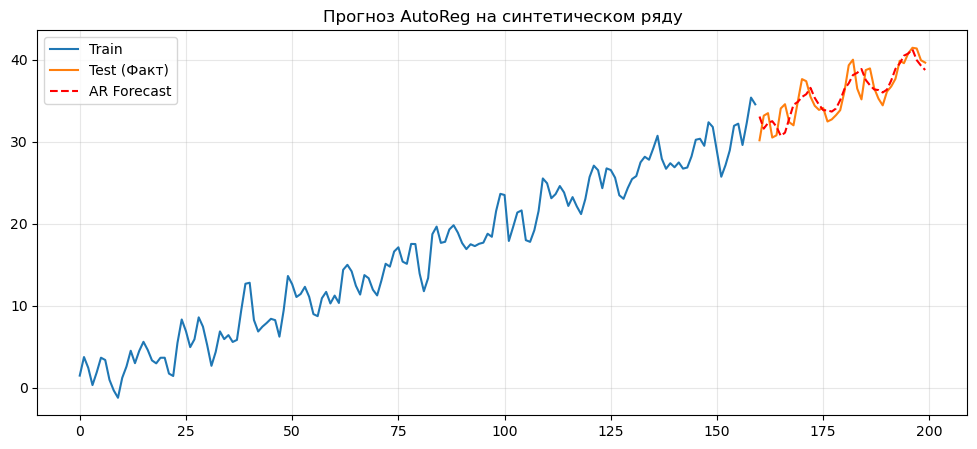

МЕТРИКИ КАЧЕСТВА ПРОГНОЗА:
RMSE:  1.6064
MAPE:  0.0372
MAE:   1.3046
R2:    0.7292
SMAPE: 3.7137%


In [41]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score

# 1. Разобьем данные на train и test 80/20
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

y_train = train_df['x']
y_test = test_df['x']

# 2. Обучаем модель.
# есть тренд (trend='t') и сезонность с периодом 12 (seasonal=True, period=12).
# Выберем лаги (можно через ar_select_order, но возьмем lags=3 для AR-процесса).
model = AutoReg(y_train, lags=3, trend='t', seasonal=True, period=12)
res = model.fit()

# 3. Делаем прогноз
forecast = res.predict(start=test_df.index[0], end=test_df.index[-1], dynamic=False)

# 4. Отрисовка
plt.figure(figsize=(12, 5))
plt.plot(train_df['t'], y_train, label="Train")
plt.plot(test_df['t'], y_test, label="Test (Факт)")
plt.plot(test_df['t'], forecast, label="AR Forecast", color='red', linestyle='--')
plt.title("Прогноз AutoReg на синтетическом ряду")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. Считаем метрики, включая написанную SMAPE
def smape(a, f):
    return 100 / len(a) * np.sum(2 * np.abs(f - a) / (np.abs(a) + np.abs(f)))

print("МЕТРИКИ КАЧЕСТВА ПРОГНОЗА:")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_test, forecast)):.4f}")
print(f"MAPE:  {mean_absolute_percentage_error(y_test, forecast):.4f}")
print(f"MAE:   {mean_absolute_error(y_test, forecast):.4f}")
print(f"R2:    {r2_score(y_test, forecast):.4f}")
print(f"SMAPE: {smape(y_test.values, forecast.values):.4f}%")